In [40]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from lightgbm import early_stopping, log_evaluation

Enable CUDA before running this notebook.

In this notebook we analyze behaviral data using time series models and generate new features to completement the main dataset which only uses aggregation like mean or max. Each applicant gets a table of select features over a span of 96 months, and we train a model to embed the table and use it to predict labels. 

- Bureau AUC: 0.6254
- Pos_cash AUC: 0.6108
- Credit AUC: 0.6711

In the training we use BCEWithLogitsLoss to account for the imbalance in target variable distribution, as seen in the main notebook. For binary classification the loss per sample is 
$$L = −\left[ y \log(p) + (1−y) \log(1−p) \right]$$
which is biased because most of the samples aren't fraud. But if we use
$$L = −\left[ weight_{pos} * y * log(p) + (1−y) log(1−p) \right]$$
now the class is balanced if we just set a lower pos_weight. 

Finally, we append the hidden state of the last timepoint in LSTM to our original dataset, which would contain longitudinal information on the customer's habit for returning money. This information is previously not available to model when we simply aggregate months of return histories into a couple of numbers.

# Model Training

In [2]:
class CreditModel(nn.Module):
    def __init__(self, n_features, hidden_size):
        super().__init__()

        self.conv = nn.Conv1d(
            in_channels=n_features,
            out_channels=32,
            kernel_size=2
        )

        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # (batch, time, features) → (batch, features, time)
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        # back to (batch, time, features)
        x = x.permute(0, 2, 1)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.fc(x)
        return x

    def get_encoding(self, x):
        with torch.no_grad():
            x = x.permute(0, 2, 1)
            x = self.conv(x)
            x = x.permute(0, 2, 1)
            x, _ = self.lstm(x)
            x = x[:, -1, :]
        return x

In [3]:
def train_model(model, X, y, epochs=15, batch_size=256, lr=1e-3, val_split=0.2):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    dataset = TensorDataset(X, y)
    n_val = int(len(dataset) * val_split)
    n_train = len(dataset) - n_val

    train_ds, val_ds = random_split(dataset, [n_train, n_val])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    pos_weight = torch.tensor([(len(y)-y.sum())/y.sum()])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):

        # ---- train ----
        model.train()
        train_loss = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            preds = model(xb).squeeze()
            loss = criterion(preds, yb)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ---- validation ----
        model.eval()
        val_loss = 0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                preds = model(xb).squeeze()
                loss = criterion(preds, yb)

                val_loss += loss.item()

                all_preds.append(preds.cpu())
                all_targets.append(yb.cpu())

        val_loss /= len(val_loader)

        all_preds = torch.sigmoid(torch.cat(all_preds)).numpy()
        all_targets = torch.cat(all_targets).numpy()
    
        auc = roc_auc_score(all_targets, all_preds)

        print(f"epoch {epoch} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_auc {auc:.4f}")

In [4]:
ID_MAP = {}
train = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv') 
bureau = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/bureau.csv')
bureau_balance = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv')
bb = bureau_balance.merge(
    bureau[['SK_ID_BUREAU','SK_ID_CURR']],
    on='SK_ID_BUREAU',
    how='left'
)
bb = bb.loc[bb['SK_ID_CURR'].isna() == 0]
POS_CASH_balance = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv')
credit_card_balance = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv')

In [5]:
s = set(train['SK_ID_CURR'])
s1 = set(bb['SK_ID_CURR'].unique()) & s
s2 = set(POS_CASH_balance['SK_ID_CURR'].unique()) & s
s3 = set(credit_card_balance['SK_ID_CURR'].unique()) & s

print({
    "total": train.shape[0],
    "bb": len(s1),
    'pos_cash': len(s2),
    'credit_card': len(s3),
})

{'total': 307511, 'bb': 92231, 'pos_cash': 289444, 'credit_card': 86905}


It looks like if we were to concatenate time-series features we would have a dataframe with a huge number of nans... therefore we train separate model and then combine feature. 

In [6]:
train = train.set_index('SK_ID_CURR')

## Bureau 

In [7]:
bb = bb[bb['SK_ID_CURR'].isin(s1)]
status_map = {
    'X': -1,   # no loan
    'C': 0,    # closed / paid
    '0': 1,    # current
    '1': 2,
    '2': 3,
    '3': 4,
    '4': 5,
    '5': 6
}
bb['STATUS'] = bb['STATUS'].map(status_map)
bb_group = bb.groupby(['SK_ID_CURR', 'MONTHS_BALANCE']).agg(
        worst_status = ('STATUS', 'max'),
        mean_status = ('STATUS', 'mean'),
        number_of_records = ('STATUS','count')
    )
bureau_ids, bureau_dfs = [], []

for _ in range(len(s1)):
    df = pd.DataFrame(index=range(-96, 0))
    df.index.name = "MONTHS_BALANCE"
    bureau_dfs.append(df)

for i, (sk_id, monthly) in enumerate(bb_group.groupby(level=0)):
    monthly = monthly.droplevel(0)
    bureau_ids.append(sk_id)
    bureau_dfs[i] = bureau_dfs[i].join(monthly, how = 'left', on = 'MONTHS_BALANCE')

labels = train.loc[bureau_ids, 'TARGET']

In [8]:
X = np.stack([
    df.to_numpy(dtype=np.float32)
    for df in bureau_dfs
])

X = np.nan_to_num(X)
y = labels.to_numpy()

X_tensor_bureau = torch.tensor(X, dtype=torch.float32)
y_tensor_bureau = torch.tensor(y, dtype=torch.float32)
mean = X_tensor_bureau.mean(axis=(0,1), keepdims=True)
std = X_tensor_bureau.std(axis=(0,1), keepdims=True) + 1e-6
X_tensor_bureau = (X_tensor_bureau - mean) / std

In [10]:
model_bureau = CreditModel(n_features=X_tensor_bureau.shape[2], hidden_size = 32)
train_model(model_bureau, X_tensor_bureau, y_tensor_bureau, epochs = 15)

epoch 0 | train_loss 1.2637 | val_loss 1.2595 | val_auc 0.5791
epoch 1 | train_loss 1.2563 | val_loss 1.2530 | val_auc 0.5907
epoch 2 | train_loss 1.2546 | val_loss 1.2505 | val_auc 0.5950
epoch 3 | train_loss 1.2511 | val_loss 1.2442 | val_auc 0.6026
epoch 4 | train_loss 1.2482 | val_loss 1.2423 | val_auc 0.6102
epoch 5 | train_loss 1.2474 | val_loss 1.2413 | val_auc 0.6086
epoch 6 | train_loss 1.2460 | val_loss 1.2402 | val_auc 0.6139
epoch 7 | train_loss 1.2451 | val_loss 1.2454 | val_auc 0.6068
epoch 8 | train_loss 1.2456 | val_loss 1.2451 | val_auc 0.6124
epoch 9 | train_loss 1.2423 | val_loss 1.2353 | val_auc 0.6207
epoch 10 | train_loss 1.2428 | val_loss 1.2528 | val_auc 0.5882
epoch 11 | train_loss 1.2441 | val_loss 1.2400 | val_auc 0.6115
epoch 12 | train_loss 1.2421 | val_loss 1.2415 | val_auc 0.6101
epoch 13 | train_loss 1.2376 | val_loss 1.2379 | val_auc 0.6226
epoch 14 | train_loss 1.2360 | val_loss 1.2366 | val_auc 0.6207


## Pos_cash 

In [11]:
POS_CASH_balance = POS_CASH_balance[POS_CASH_balance['SK_ID_CURR'].isin(s2)]

pos_monthly = POS_CASH_balance.groupby(['SK_ID_CURR','MONTHS_BALANCE']).agg(
    sk_dpd_max=('SK_DPD','max'),
    sk_dpd_mean=('SK_DPD','mean'),
    sk_dpd_def_max=('SK_DPD_DEF','max'),
    sk_dpd_def=('SK_DPD_DEF','mean'),
    cnt_instalment_future_mean=('CNT_INSTALMENT_FUTURE','mean'),
    number_of_active_loans = ('NAME_CONTRACT_STATUS', lambda x: (x== 'Active').sum()),
    number_of_inactive_loans = ('NAME_CONTRACT_STATUS', lambda x: (x!= 'Active').sum())
)

cash_ids, cash_dfs = [], []

for _ in range(len(s2)):
    df = pd.DataFrame(index=range(-96, 0))
    df.index.name = "MONTHS_BALANCE"
    cash_dfs.append(df)

for i, (sk_id, monthly) in enumerate(pos_monthly.groupby(level=0)):
    monthly = monthly.droplevel(0)
    cash_ids.append(sk_id)
    cash_dfs[i] = cash_dfs[i].join(monthly, how = 'left', on = 'MONTHS_BALANCE')
cash_labels = train.loc[cash_ids, 'TARGET']

In [12]:
X = np.stack([
    df.to_numpy(dtype=np.float32)
    for df in cash_dfs
])
X = np.nan_to_num(X)
y = cash_labels.to_numpy()
X_tensor_cash = torch.tensor(X, dtype=torch.float32)
y_tensor_cash = torch.tensor(y, dtype=torch.float32)
mean = X_tensor_cash.mean(axis=(0,1), keepdims=True)
std = X_tensor_cash.std(axis=(0,1), keepdims=True) + 1e-6
X_tensor_cash = (X_tensor_cash - mean) / std

In [13]:
model_cash = CreditModel(n_features=X_tensor_cash.shape[2], hidden_size = 32)
train_model(model_cash, X_tensor_cash, y_tensor_cash, epochs = 20)

epoch 0 | train_loss 1.2682 | val_loss 1.2739 | val_auc 0.5412
epoch 1 | train_loss 1.2653 | val_loss 1.2708 | val_auc 0.5472
epoch 2 | train_loss 1.2624 | val_loss 1.2660 | val_auc 0.5607
epoch 3 | train_loss 1.2561 | val_loss 1.2842 | val_auc 0.5670
epoch 4 | train_loss 1.2622 | val_loss 1.2687 | val_auc 0.5491
epoch 5 | train_loss 1.2592 | val_loss 1.2645 | val_auc 0.5673
epoch 6 | train_loss 1.2521 | val_loss 1.2568 | val_auc 0.5814
epoch 7 | train_loss 1.2554 | val_loss 1.2631 | val_auc 0.5597
epoch 8 | train_loss 1.2526 | val_loss 1.2535 | val_auc 0.5914
epoch 9 | train_loss 1.2442 | val_loss 1.2604 | val_auc 0.5689
epoch 10 | train_loss 1.2584 | val_loss 1.2689 | val_auc 0.5490
epoch 11 | train_loss 1.2564 | val_loss 1.2645 | val_auc 0.5569
epoch 12 | train_loss 1.2518 | val_loss 1.2514 | val_auc 0.5938
epoch 13 | train_loss 1.2430 | val_loss 1.2483 | val_auc 0.5990
epoch 14 | train_loss 1.2420 | val_loss 1.2475 | val_auc 0.5999
epoch 15 | train_loss 1.2455 | val_loss 1.2542 | v

## Credit_card 

In [14]:
credit_card_balance = credit_card_balance[credit_card_balance['SK_ID_CURR'].isin(s3)]
credit_card_balance['payment_ratio'] = credit_card_balance['AMT_PAYMENT_TOTAL_CURRENT'] / credit_card_balance['AMT_INST_MIN_REGULARITY']
credit_card_balance['payment_ratio'] = credit_card_balance['payment_ratio'].clip(-1e9, 1e9)
credit_card_balance['utilization'] = credit_card_balance['AMT_BALANCE'] / credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL']
credit_card_balance['utilization'] = credit_card_balance['utilization'].clip(-1e9, 1e9)
credit_card_balance['draw_vs_pay'] = credit_card_balance['AMT_DRAWINGS_CURRENT'] / credit_card_balance['AMT_PAYMENT_TOTAL_CURRENT']
credit_card_balance['draw_vs_pay'] = credit_card_balance['draw_vs_pay'].clip(-1e9, 1e9)
credit_card_balance['draw_vs_limit'] = credit_card_balance['AMT_DRAWINGS_CURRENT'] / credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL']
credit_card_balance['draw_vs_limit'] = credit_card_balance['draw_vs_limit'].clip(-1e9, 1e9)

credit_monthly = credit_card_balance.groupby(['SK_ID_CURR','MONTHS_BALANCE']).agg(
        NUMBER_OF_DEBT = ('AMT_BALANCE', 'count'),
        AMT_BALANCE_mean = ('AMT_BALANCE','mean'),
        AMT_BALANCE_sum = ('AMT_BALANCE','sum'),
        AMT_credit_limit_mean = ('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
        AMT_credit_limit_min = ('AMT_CREDIT_LIMIT_ACTUAL', 'min'),
        AMT_drawings_sum = ('AMT_DRAWINGS_ATM_CURRENT', 'sum'),
        AMT_drawings_mean = ('AMT_DRAWINGS_ATM_CURRENT', 'mean'),
        AMT_DRAWINGS_OTHER_CURRENT_sum = ('AMT_DRAWINGS_OTHER_CURRENT', 'sum'),
        AMT_DRAWINGS_OTHER_CURRENT_mean = ('AMT_DRAWINGS_OTHER_CURRENT', 'mean'),
        AMT_DRWAINGS_POS_CURRENT_sum = ('AMT_DRAWINGS_POS_CURRENT', 'sum'),
        AMT_DRWAINGS_POS_CURRENT_mean = ('AMT_DRAWINGS_POS_CURRENT', 'mean'),
        AMT_INST_MIN_REGULARITY_sum = ('AMT_INST_MIN_REGULARITY', 'sum'),
        AMT_INST_MIN_REGULARITY_mean = ('AMT_INST_MIN_REGULARITY', 'mean'),
        PAYMENT_RATIO_mean = ('payment_ratio', 'mean'),
        UTILIZATION_mean = ('utilization', 'mean'),
        DRAWVSPAY_mean = ('draw_vs_pay', 'mean'),
        DRAWVSLIMIT_mean = ('draw_vs_limit', 'mean'),
        AMT_PAYMENT_CURRENT_mean = ('AMT_PAYMENT_CURRENT', 'mean'),
        AMT_PAYMENT_CURRENT_sum = ('AMT_PAYMENT_CURRENT', 'sum'),
        AMT_PAYMENT_TOTAL_CURRENT_mean = ('AMT_PAYMENT_TOTAL_CURRENT', 'mean'),
        AMT_PAYMENT_TOTAL_CURRENT_sum = ('AMT_PAYMENT_TOTAL_CURRENT', 'sum'),
        AMT_RECEIVABLE_PRINCIPAL_mean = ('AMT_RECEIVABLE_PRINCIPAL', 'mean'),
        AMT_RECEIVABLE_PRINCIPAL_sum = ('AMT_RECEIVABLE_PRINCIPAL', 'sum'),
        AMT_RECIVABLE_sum = ('AMT_RECIVABLE', 'sum'),
        AMT_RECIVABLE_mean = ('AMT_RECIVABLE', 'mean'),
        AMT_TOTAL_RECEIVABLE_sum = ('AMT_TOTAL_RECEIVABLE', 'sum'),
        AMT_TOTAL_RECEIVABLE_mean = ('AMT_TOTAL_RECEIVABLE', 'mean'),
        CNT_DRAWINGS_ATM_CURRENT_sum = ('CNT_DRAWINGS_ATM_CURRENT', 'sum'),
        CNT_DRAWINGS_ATM_CURRENT_mean = ('CNT_DRAWINGS_ATM_CURRENT', 'mean'),
        CNT_DRAWINGS_CURRENT_sum = ('CNT_DRAWINGS_CURRENT', 'sum'),
        CNT_DRAWINGS_CURRENT_mean = ('CNT_DRAWINGS_CURRENT', 'mean'),
        CNT_DRAWINGS_OTHER_CURRENT_mean = ('CNT_DRAWINGS_OTHER_CURRENT', 'mean'),
        CNT_DRAWINGS_OTHER_CURRENT_sum = ('CNT_DRAWINGS_OTHER_CURRENT', 'sum'),
        CNT_DRAWINGS_POS_CURRENT_mean = ('CNT_DRAWINGS_POS_CURRENT', 'mean'),
        CNT_DRAWINGS_POS_CURRENT_sum = ('CNT_DRAWINGS_POS_CURRENT', 'sum'),
        CNT_INSTALMENT_MATURE_CUM_mean = ('CNT_INSTALMENT_MATURE_CUM', 'mean'),
        CNT_INSTALMENT_MATURE_CUM_sum = ('CNT_INSTALMENT_MATURE_CUM', 'sum'),
        credit_SK_DPD_mean = ('SK_DPD', 'mean'),
        credit_SK_DPD_sum = ('SK_DPD', 'sum'),
        credit_SK_DPD_DEF_mean = ('SK_DPD_DEF', 'mean'),
        credit_SK_DPD_DEF_sum = ('SK_DPD_DEF', 'sum'),
        credit_card_active_count = ('NAME_CONTRACT_STATUS', lambda x: (x=='Active').sum()),
        credit_card_inactive_count = ('NAME_CONTRACT_STATUS', lambda x: (x!='Active').sum())
)

In [15]:
credit_ids = []
credit_dfs = []

for _ in range(len(s3)):
    df = pd.DataFrame(index=range(-96, 0))
    df.index.name = "MONTHS_BALANCE"
    credit_dfs.append(df)

for i, (sk_id, monthly) in enumerate(credit_monthly.groupby(level=0)):
    monthly = monthly.droplevel(0)
    credit_ids.append(sk_id)
    credit_dfs[i] = credit_dfs[i].join(monthly, how = 'left', on = 'MONTHS_BALANCE')
credit_labels = train.loc[credit_ids, 'TARGET']

In [16]:
X = np.stack([
    df.to_numpy(dtype=np.float32)
    for df in credit_dfs
])
X = np.nan_to_num(X)
y = credit_labels.to_numpy()
X_tensor_credit = torch.tensor(X, dtype=torch.float32)
y_tensor_credit = torch.tensor(y, dtype=torch.float32)
mean = X_tensor_credit.mean(axis=(0,1), keepdims=True)
std = X_tensor_credit.std(axis=(0,1), keepdims=True) + 1e-6
X_tensor_credit = (X_tensor_credit - mean) / std

In [17]:
X_tensor_credit.shape

torch.Size([86905, 96, 43])

In [18]:
model_credit = CreditModel(n_features=X_tensor_credit.shape[2], hidden_size = 32)
train_model(model_credit, X_tensor_credit, y_tensor_credit, epochs = 10)

epoch 0 | train_loss 1.2003 | val_loss 1.1917 | val_auc 0.6676
epoch 1 | train_loss 1.1823 | val_loss 1.1890 | val_auc 0.6698
epoch 2 | train_loss 1.1774 | val_loss 1.1870 | val_auc 0.6720
epoch 3 | train_loss 1.1747 | val_loss 1.1867 | val_auc 0.6712
epoch 4 | train_loss 1.1727 | val_loss 1.1865 | val_auc 0.6727
epoch 5 | train_loss 1.1698 | val_loss 1.1850 | val_auc 0.6731
epoch 6 | train_loss 1.1674 | val_loss 1.1876 | val_auc 0.6717
epoch 7 | train_loss 1.1665 | val_loss 1.1850 | val_auc 0.6700
epoch 8 | train_loss 1.1645 | val_loss 1.1816 | val_auc 0.6749
epoch 9 | train_loss 1.1617 | val_loss 1.1841 | val_auc 0.6720


# Feature Generation + Final AUC

In [19]:
def encode_in_batches(model, X_tensor, ids, batch_size=256, prefix="feat"):
    
    model.eval()
    outputs = []
    
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            batch = X_tensor[i:i+batch_size]
            enc = model.get_encoding(batch)
            outputs.append(enc.cpu())
    
    outputs = torch.cat(outputs, dim=0).numpy()
    
    df = pd.DataFrame(outputs, index=ids)
    df.columns = [f"{prefix}_{i}" for i in range(df.shape[1])]
    
    return df

In [ ]:
cash_df = encode_in_batches(
    model_cash, X_tensor_cash, cash_ids, batch_size=256, prefix="cash"
)

credit_df = encode_in_batches(
    model_credit, X_tensor_credit, credit_ids, batch_size=256, prefix="credit"
)

bureau_df = encode_in_batches(
    model_bureau, X_tensor_bureau, bureau_ids, batch_size=256, prefix="bureau"
)

deep_learning_df = cash_df.join(
    [credit_df, bureau_df],
    how='left'
)
deep_learning_df.index.name = "SK_ID_CURR"
deep_learning_df = deep_learning_df.reset_index()
deep_learning_df.to_csv('deep_learning_features.csv')

In [23]:
train_final = pd.read_csv('/kaggle/input/datasets/leoliu1415/features-for-home-credit-dataset/train_final.csv')
train_final = train_final.merge(
    deep_learning_df,
    on = 'SK_ID_CURR',
    how = 'left'
)

In [37]:
y = train_final['TARGET']
X = train_final.drop(['TARGET', 'SK_ID_CURR'], axis=1)
cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = X[cat_cols].astype('category')

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=450,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50
)

TypeError: XGBClassifier.fit() got an unexpected keyword argument 'callbacks'

In [43]:
import re

def clean_col_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', col)  # keep only letters, numbers, underscore
        for col in df.columns
    ]
    return df

X_train = clean_col_names(X_train)
X_valid = clean_col_names(X_valid)

In [44]:
model_2 = LGBMClassifier(
    n_estimators=10000,          # large, rely on early stopping
    learning_rate=0.01,          # smaller LR → better generalization
    
    num_leaves=64,               # key parameter (controls complexity)
    max_depth=-1,                # let num_leaves control depth
    
    min_child_samples=50,        # prevents overfitting
    subsample=0.8,               # row sampling
    subsample_freq=1,
    
    colsample_bytree=0.8,        # feature sampling
    
    reg_alpha=1.0,               # L1 regularization
    reg_lambda=1.0,              # L2 regularization
    
    objective='binary',
    random_state=42,
    n_jobs=-1
)

model_2.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='auc',
    callbacks=[
        early_stopping(100),
        log_evaluation(50)
    ]
)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.874179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 57174
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 424
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
[50]	valid_0's auc: 0.757235	valid_0's binary_logloss: 0.260123
[100]	valid_0's auc: 0.763625	valid_0's binary_logloss: 0.251501
[150]	valid_0's auc: 0.769732	valid_0's binary_logloss: 0.246639
[200]	valid_0's auc: 0.774214	valid_0's binary_logloss: 0.243607
[250]	valid_0's auc: 0.777884	valid_0's binary_logloss: 0.241494
[300]	valid_0's auc: 0.781236	valid_0's binary_logloss: 0.239873
[350]	valid_0's auc: 0.783781	valid_0's binary_logl

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.01, min_child_samples=50,
               n_estimators=10000, n_jobs=-1, num_leaves=64, objective='binary',
               random_state=42, reg_alpha=1.0, reg_lambda=1.0, subsample=0.8,
               subsample_freq=1)

In [47]:
y_pred = model_2.predict(X_valid)
y_prob = model_2.predict_proba(X_valid)[:,1]

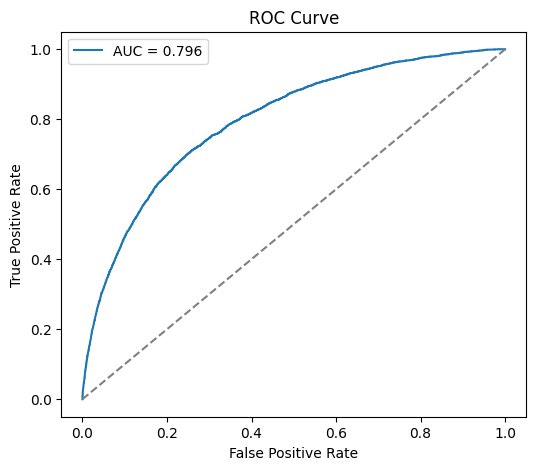

In [48]:
fpr, tpr, _ = roc_curve(y_valid, y_prob)
roc_auc = roc_auc_score(y_valid, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()